# We use the 300 csv files created and implement a direct contest against the r codes.
# Takes 14.8 Minutes per Simulation.

In [1]:
%run -i ~/project/preambles
%run -i ~/project/helper_functions
%run -i ~/project/fitting_functions

In [2]:
# # Global parameters:
number_of_cycles = 500 # how many passes through the training data we go through
number_of_groups = 1 # divide the data set into smaller ones, to make fitting easier.
locations_per_group = 200 # how many locations to observe per group
number_of_locations = number_of_groups * locations_per_group # total locations
number_of_simulations = 300 # for synthetic data, how many optimisation to average over
steps_per_batch = 5
dims = 2  # 2D spatial
p =  3 # how many features 

In [3]:
X,Y,true_K, alpha_matrix_true, nu_matrix_true, sigma_matrix_true = Genton_parametrisation(number_of_locations, dims)
ground_truth_df = store_as_df(alpha_matrix_true, nu_matrix_true, sigma_matrix_true)
estimated_params_df = pd.DataFrame()
distance_K_df = pd.DataFrame()

for _ in range(1,301):
    print(f"data set {_}")
    try:
        # Load the CSV file
        df = pd.read_csv(f'~/project/synthetic_data/realisation_{_}.csv')
        # Extract the spatial coordinates (first and second spatial coordinates)
        X = torch.tensor(df[['0','1']].values[:200], dtype=torch.float64).detach()
        # Prepare Y by reshaping the gene expression levels for each gene
        expression = df['Expression'].values.reshape(200, 3)
        Y = torch.tensor(expression, dtype=torch.float64).detach()
        torch.autograd.set_detect_anomaly(True)
        optimized_marginal_params = optimize_marginal_parameters(X, Y, number_of_groups,  number_of_cycles, steps_per_batch)
        alpha_matrix, nu_matrix, sigma_matrix = optimize_cross_parameters(optimized_marginal_params,X,Y,number_of_groups,number_of_cycles,steps_per_batch)
        estimated_K = compute_matern_covariance(alpha_matrix, nu_matrix, sigma_matrix, X)
        distance_K = torch.norm(true_K - estimated_K)**2 / torch.norm(true_K)**2
        distance_K_df = pd.concat([distance_K_df, pd.DataFrame([distance_K.item()])] ,ignore_index=True)
        estimated_params_df = pd.concat([estimated_params_df, store_as_df(alpha_matrix, nu_matrix, sigma_matrix) ], ignore_index=True)
        # Save the combined DataFrame to a CSV file
        file_path = os.path.expanduser(f'~/project/python_processed_data/synthetic_estimated_parameters_2.csv')
        estimated_params_df.to_csv(file_path, index=False)
    except Exception as e:
        print(e)
        continue
estimated_params_df

data set 1


Condition failed at epoch 0, halving learning rate. Attempt 1
Condition failed at epoch 0, halving learning rate. Attempt 2
epoch 0 step 0 succeeded with learning rate: 0.00025


Condition failed at epoch 1, halving learning rate. Attempt 1


Condition failed at epoch 51, halving learning rate. Attempt 1
Condition failed at epoch 51, halving learning rate. Attempt 2
epoch 51 step 0 succeeded with learning rate: 0.00025


Condition failed at epoch 73, halving learning rate. Attempt 1
Condition failed at epoch 73, halving learning rate. Attempt 2
epoch 73 step 3 succeeded with learning rate: 0.00025


...

Condition failed at epoch 0, halving learning rate. Attempt 1
Condition failed at epoch 0, halving learning rate. Attempt 2
epoch 0 step 0 succeeded with learning rate: 0.00025



Learning Rate Halving Log: ['Epoch 0: LR halved at attempt 1', 'Epoch 0: LR halved at attempt 2']
data set 299


Condition failed at epoch 0, halving learning rate. Attempt 1
Condition failed at epoch 0, halving learning rate. Attempt 2
epoch 0 step 0 succeeded with learning rate: 0.00025



Learning Rate Halving Log: ['Epoch 0: LR halved at attempt 1', 'Epoch 0: LR halved at attempt 2']
data set 300


,alpha_matrix_11,nu_matrix_11,sigma_matrix_11,alpha_matrix_12,nu_matrix_12,sigma_matrix_12,alpha_matrix_13,nu_matrix_13,sigma_matrix_13,alpha_matrix_22,nu_matrix_22,sigma_matrix_22,alpha_matrix_23,nu_matrix_23,sigma_matrix_23,alpha_matrix_33,nu_matrix_33,sigma_matrix_33
0,2.220446e-16,0.978202,0.799805,0.937233,1.878728,-3.846358e-20,0.938822,1.513636,-2.506913e-14,2.220446e-16,1.020926,1.078323,0.938822,1.534998,-9.066124e-14,7.721148e-02,0.290741,0.998196
1,2.660229e-02,1.851241,1.031967,0.900606,3.588304,-1.357577e-32,0.900840,1.821839,-4.054866e-33,3.841384e-02,3.705367,1.148679,0.901053,2.748902,-6.130652e-33,4.814499e-02,0.172437,0.930699
2,5.136598e-02,3.765748,1.023731,0.253503,5.392817,-1.103290e-27,0.254815,5.316920,-7.845503e-28,2.588716e-03,2.000987,1.068435,0.252219,4.434539,-3.639463e-29,3.660418e-02,1.849193,1.025085
3,9.022952e-02,0.026058,1.110081,0.934090,1.394380,-2.577316e-33,0.934090,1.392864,-2.579357e-33,2.220446e-16,1.024979,0.841959,0.931909,1.892324,-2.335171e-33,2.220446e-16,1.021946,1.033313
4,3.585729e-02,3.818589,0.730174,0.918330,3.242014,-7.453872e-09,0.918330,3.263804,-7.607455e-09,2.220446e-16,0.980051,1.092432,0.917980,1.844534,-3.187847e-09,2.220446e-16,1.023629,1.157901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.001482e-02,1.802892,0.929563,0.905053,3.150899,-5.932221e-21,0.904958,1.774904,-1.933977e-21,1.854011e-02,3.735262,0.992400,0.905025,2.741089,-1.578869e-09,2.220446e-16,0.983272,1.105893
296,8.810847e-03,3.766828,0.915261,0.920182,3.232173,-6.167167e-33,0.920182,3.231755,-6.164783e-33,2.220446e-16,1.017769,1.039539,0.920161,1.857225,-2.909511e-33,2.220446e-16,1.016933,0.970624
297,8.402010e-03,1.863680,1.058884,0.908589,2.766311,-4.321201e-21,0.908589,2.766085,-4.320642e-21,2.220446e-16,0.983175,1.132745,0.908569,2.325833,-4.514383e-09,2.220446e-16,0.982724,1.151002
298,2.220446e-16,1.016741,0.912981,0.947318,2.324717,-1.739197e-33,0.947074,1.924710,-1.614877e-33,3.036526e-02,1.816795,1.042052,0.947318,2.324737,-1.739209e-33,2.220446e-16,1.016780,0.989213


DataFrame saved to /home/zc362/project/python_processed_data/fitted_parameters_1.csv


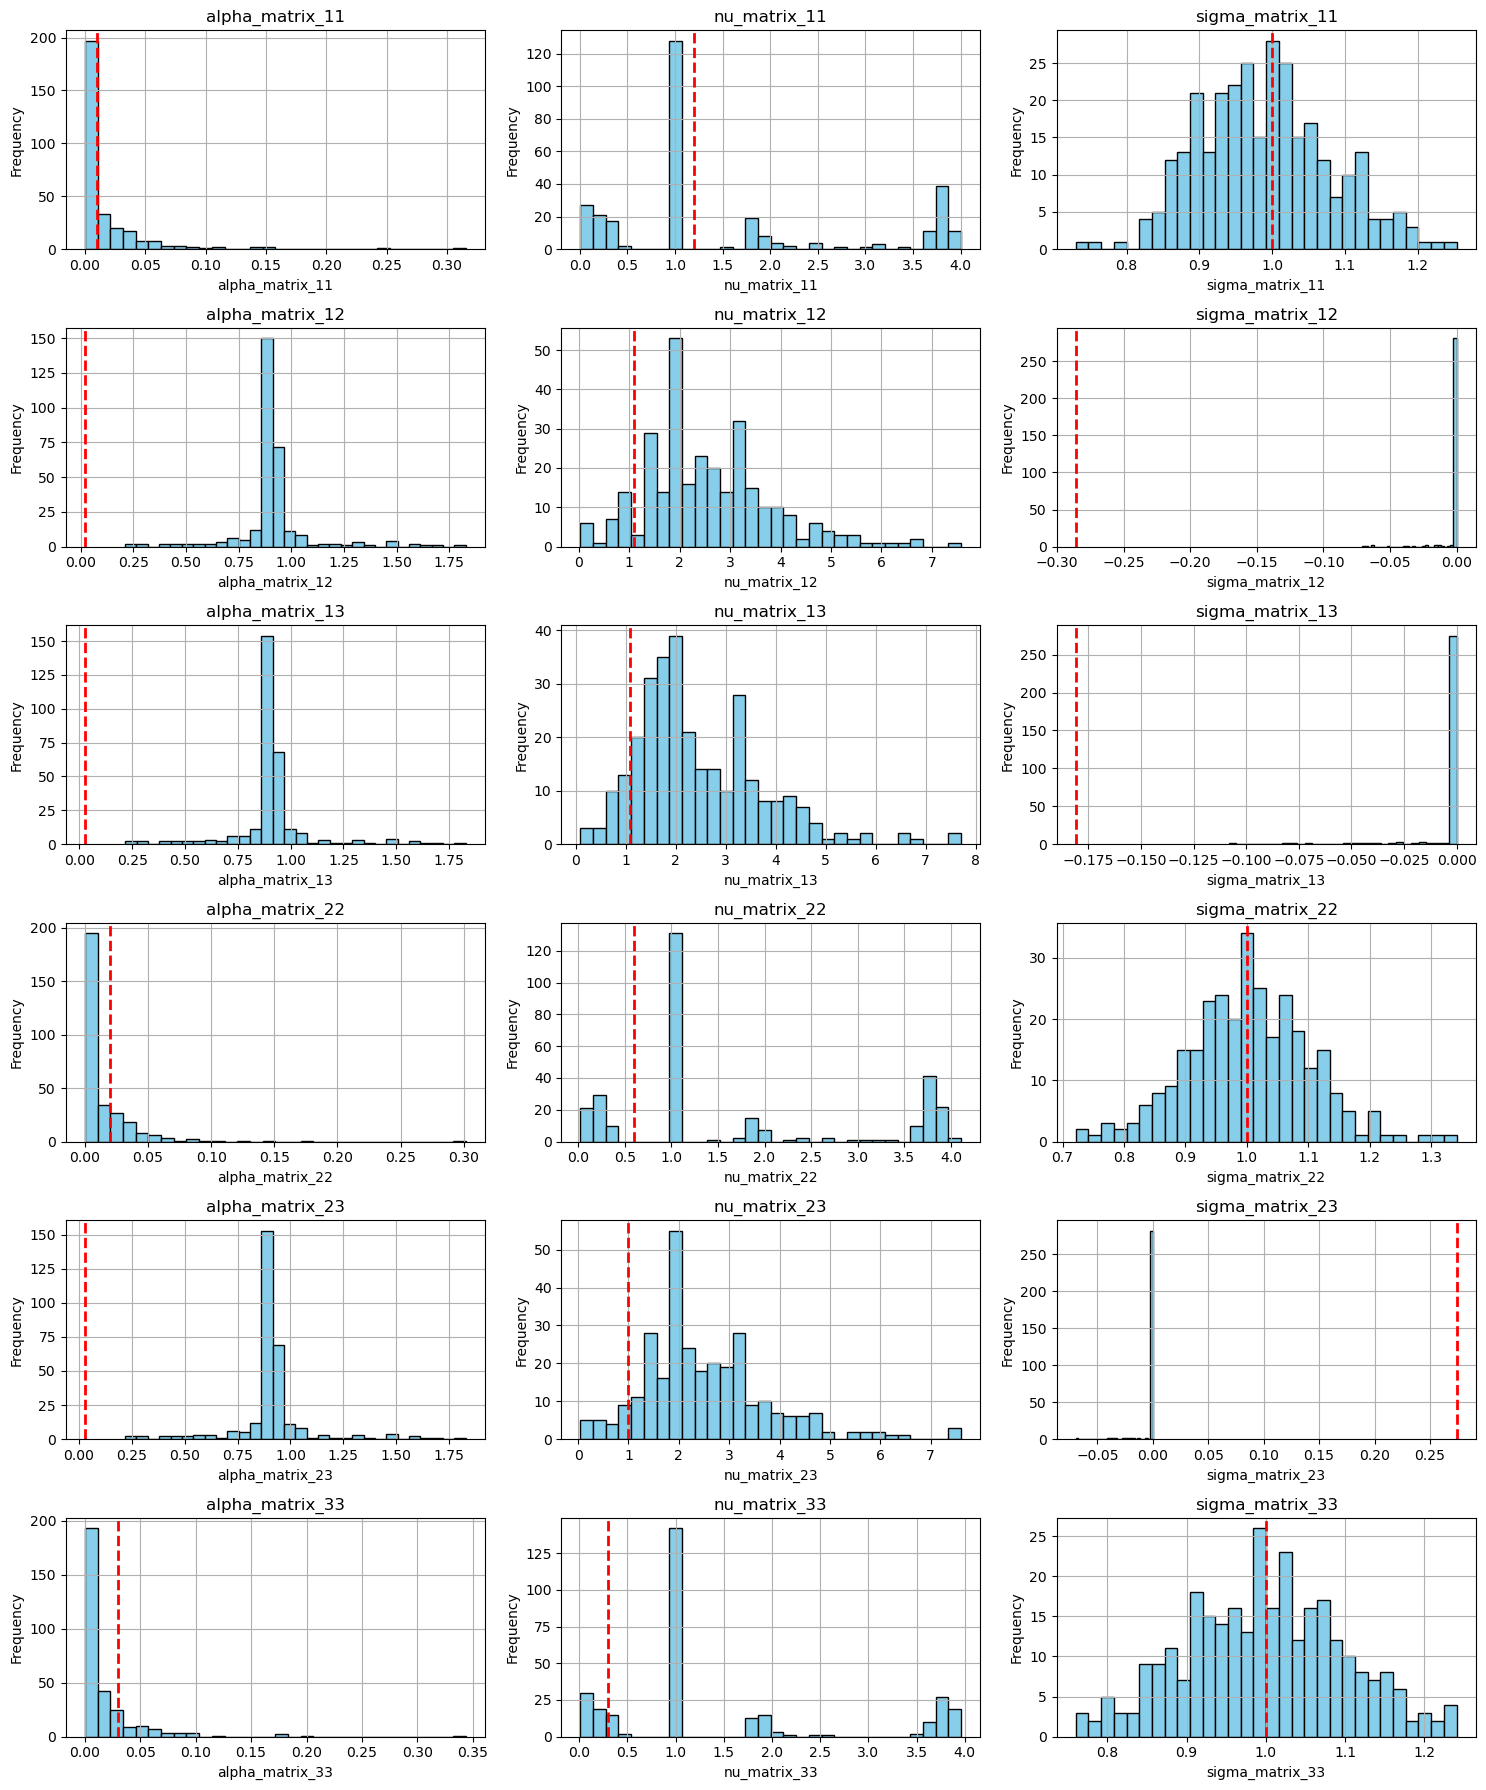

In [4]:
histograms_are_plotted = True
df_to_plot = estimated_params_df
%run -i epilogue

(array([  3.,  36., 143.,  85.,  21.,   9.,   2.,   0.,   0.,   1.]),
 array([0.10355419, 0.11338471, 0.12321523, 0.13304574, 0.14287626,
        0.15270678, 0.16253729, 0.17236781, 0.18219833, 0.19202884,
        0.20185936]),
 <BarContainer object of 10 artists>)

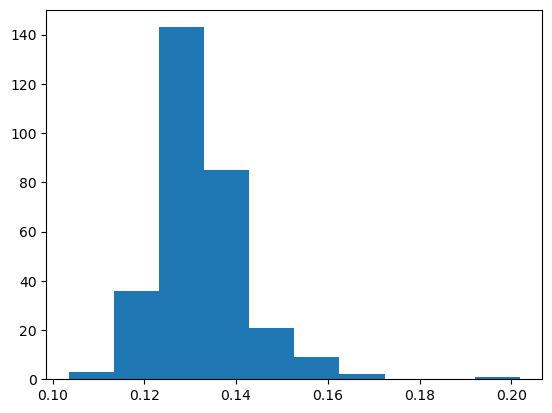

In [5]:
plt.hist(distance_K_df[0])